Note that the initial step here takes quite a while to run. Give it a few minutes.

In [1]:
import matplotlib.pyplot as plt
from MedtronicPerceptAnalysisTool import PatientDatasetRegistry
from MedtronicPerceptAnalysisTool.utility.constants import FrequencyRange
import pandas as pd
import numpy as np
from MedtronicPerceptAnalysisTool.plotter.all_patients.all_patients import plot_all_hemi_type_inter
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, wilcoxon, ranksums, mannwhitneyu, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_all = PatientDatasetRegistry().all_dataframe_lfp()
freq_range = FrequencyRange.Beta.value
normType = "non-RelC"
plt.rcParams['svg.fonttype'] = 'none' # I hate you.

nopeaks = [2,3,5,8,9]

In [2]:
from matplotlib import cm as cmap
b = []
n = []

for x,p in enumerate(df_all.groupby("PatientNumber")):
    b.append([p[1]["PatientNumber"].iloc[0],p[1]["TreatmentOrder"].iloc[0]])

ind = np.array(b).squeeze()
idic = dict(ind)

In [3]:
import glob as glob
heads = ["Patient Number","Stage","Item Number","Item Description","Score"]

updrsdat = pd.DataFrame()
for g in glob.glob("updrs-relative/*"):
    r  = pd.read_excel(g,names=heads,index_col=None,usecols=np.arange(0,5))
    updrsdat = pd.concat([updrsdat,r]).reset_index(drop=True)
updrsdat.to_csv("UPDRS_Scores.csv")

In [26]:
import copy
updrs_label = copy.deepcopy(updrsdat)
for i in range(1,len(idic)+1):
    if i != 6:
        updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Baseline", value="A) DBS-off")
        if idic[str(i)] == "dbs_off,all_on,rvs":
            updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 1", value="B) All-on")
            updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 2", value="C) RVS")
        if idic[str(i)] == "dbs_off,rvs,all_on":
            updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 2", value="B) All-on")
            updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 1", value="C) RVS")

updrs_label = updrs_label[updrs_label["Stage"] != "Treatment 1"]
updrs_label = updrs_label[updrs_label["Stage"] != "Treatment 2"]
updrs_label = updrs_label[updrs_label["Stage"] != "Baseline"]

# Starting with non-peaked analyses
# Fig 4A:

C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\850370328.py:38: RuntimeWarning: Mean of empty slice
  base.append(np.nanmean(bb))


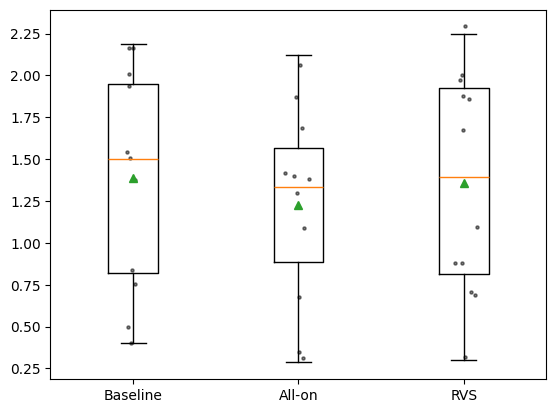

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Score   
No. Observations:    31        Method:               REML    
No. Groups:          11        Scale:                0.0455  
Min. group size:     2         Log-Likelihood:       -16.0063
Max. group size:     3         Converged:            Yes     
Mean group size:     2.8                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           1.311    0.200  6.540 0.000  0.918  1.704
Stage[T.B) All-on] -0.057    0.098 -0.588 0.557 -0.249  0.134
Stage[T.C) RVS]     0.083    0.094  0.877 0.381 -0.102  0.267
Group Var           0.390    1.061                           



In [28]:
# 4A
base = []
all  = []
rvs  = []
filename = "UPDRS_means_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p2[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
                
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        bb.append(b)
        aa.append(a)
        rr.append(r)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(np.nanmean(bb))
    if np.any(~np.isnan(aa)):
        all.append( np.nanmean(aa))
    else:
        all.append(np.nan)
    rvs.append( np.nanmean(rr))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

plt.boxplot([base,all[~np.isnan(all)],rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()


df = updrs_label.dropna(subset=["Score"]).copy()
df = (
    df.groupby(["Patient Number", "Stage"])["Score"].mean().reset_index()
)
model = smf.mixedlm( "Score ~ Stage ", data=df, groups=df["Patient Number"]).fit()
print(model.summary())

# Fig 4B:


C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\163350420.py:39: RuntimeWarning: Mean of empty slice
  all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\163350420.py:42: RuntimeWarning: Mean of empty slice
  rvs.append( np.nanmean(rr)-np.nanmean(bb))


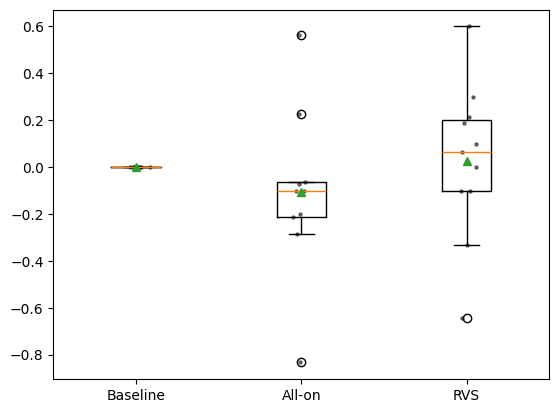

          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  subScore
No. Observations:  18       Method:              REML    
No. Groups:        9        Scale:               0.0366  
Min. group size:   2        Log-Likelihood:      -3.8055 
Max. group size:   2        Converged:           Yes     
Mean group size:   2.0                                   
---------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.05  0.95]
---------------------------------------------------------
Intercept       -0.088    0.099 -0.889 0.374 -0.251 0.075
Stage[T.C) RVS]  0.125    0.090  1.383 0.167 -0.024 0.273
Group Var        0.052    0.258                          

<Wald test (chi2): statistic=[[1.9139256]], p-value=0.16652784743686547, df_denom=1>
<Wald test (chi2): statistic=[[0.79107184]], p-value=0.37377622272079525, df_denom=1>


C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [31]:
# 4B
base = []
all  = []
rvs  = []
filename = "UPDRS_means_difference_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p2[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
                
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        bb.append(b)
        aa.append(a)
        rr.append(r)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(0)
    if np.any(~np.isnan(aa)):
        all.append( np.nanmean(aa)-np.nanmean(bb))
    else:
        all.append(np.nan)
    rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

plt.boxplot([base,all,rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

df_clean = updrs_label.dropna(subset=["Score"]).copy()
df_clean = (
    df_clean.groupby(["Patient Number", "Stage"])["Score"].mean().reset_index()
)
baseline_means = (
    df_clean[df_clean["Stage"] == "A) DBS-off"].groupby("Patient Number")["Score"].mean()
)
df_clean["Baseline"] = df_clean["Patient Number"].map(baseline_means)
df_clean["subScore"] = df_clean["Score"] - df_clean["Baseline"]
df_clean = df_clean.drop(columns=["Baseline"])
df_clean = df_clean[df_clean["Patient Number"] != 7]
df_clean = df_clean[df_clean["Patient Number"] != 3]
df_clean2 = df_clean[df_clean["Stage"] != "A) DBS-off"]
model = smf.mixedlm("subScore ~ Stage", data=df_clean2, groups=df_clean2["Patient Number"]).fit(method=["lbfgs"])
print(model.summary(alpha=0.10))
print(model.wald_test("Stage[T.C) RVS] = 0"))
print(model.wald_test("Intercept = 0"))


# Fig 4D:

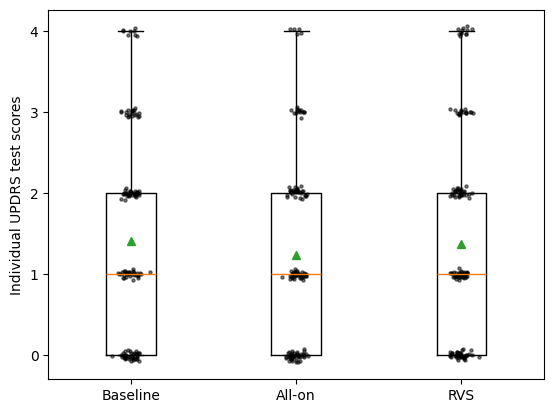

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Score    
No. Observations:   373       Method:               REML     
No. Groups:         11        Scale:                1.1944   
Min. group size:    20        Log-Likelihood:       -577.1033
Max. group size:    48        Converged:            Yes      
Mean group size:    33.9                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           1.321    0.210  6.298 0.000  0.910  1.732
Stage[T.B) All-on] -0.072    0.143 -0.504 0.615 -0.353  0.209
Stage[T.C) RVS]     0.078    0.139  0.558 0.577 -0.195  0.350
Group Var           0.369    0.168                           



In [30]:
# 4D
base = []
all  = []
rvs  = []
filename = "UPDRS_all_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p2[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
                
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        bb.append(b)
        aa.append(a)
        rr.append(r)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(bb)
    all.append(aa)
    rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()

basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,all,rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.ylabel("Individual UPDRS test scores")
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

df = updrs_label.dropna(subset=["Score"]).copy()
model = smf.mixedlm( "Score ~ Stage", data=df, groups=df["Patient Number"]).fit()
print(model.summary())
    

# Fig 4E:

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


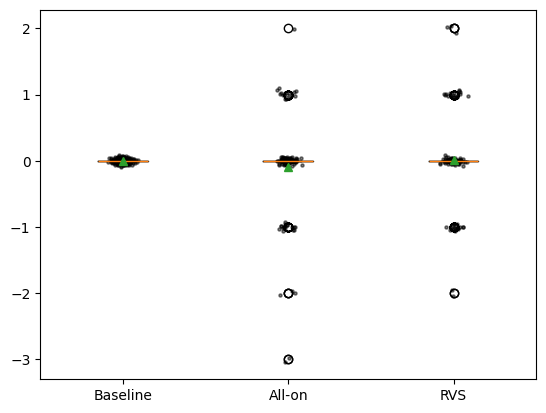

                Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      subScore
No. Observations:       219          Method:                  REML    
No. Groups:             9            Scale:                   0.3500  
Min. group size:        20           Log-Likelihood:          inf     
Max. group size:        32           Converged:               Yes     
Mean group size:        24.3                                          
----------------------------------------------------------------------
                Coef.   Std.Err.    z   P>|z|    [0.05        0.95]   
----------------------------------------------------------------------
Intercept       0.000 3794345.665 0.000 1.000 -6241143.230 6241143.230
Stage[T.C) RVS] 0.118       0.080 1.476 0.140       -0.013       0.250
Group Var       0.000                                                 

<Wald test (chi2): statistic=[[2.1791978]], p-value=0.13988735863149937, df_denom=1>
<Wald te

C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matri

In [27]:
# 4E

base = []
all  = []
rvs  = []
ixp = []
filename = "UPDRS_all_difference_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a)-np.array(b))
        rr.append(np.array(r)-np.array(b))
        bb.append(0)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(bb)
    all.append(aa)
    rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)
basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,all,rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

df_clean = updrs_label.dropna(subset=["Score"]).copy()
df_collapsed = (
    df_clean.groupby(["Patient Number", "Item Number", "Stage"])["Score"]
    .mean()
    .reset_index()
)
baseline_means = (
    df_collapsed[df_collapsed["Stage"] == "A) DBS-off"]
    .groupby(["Patient Number", "Item Number"])["Score"]
    .mean()
    .reset_index()
    .rename(columns={"Score": "Baseline_Score"})
)
df_subtracted = pd.merge(
    df_collapsed, baseline_means, on=["Patient Number", "Item Number"], how="left"
)
df_subtracted["subScore"] = (
    df_subtracted["Score"] - df_subtracted["Baseline_Score"]
)
df_clean2 = df_subtracted[df_subtracted["Stage"] != "A) DBS-off"].copy()
df_clean2 = df_clean2[df_clean2["Patient Number"] != 7]
df_clean2 = df_clean2[df_clean2["Patient Number"] != 3]
df_clean2 = df_clean2[df_clean2["Stage"] != "A) DBS-off"]
df_clean2 = df_clean2.dropna(subset=["subScore"]).copy()
model = smf.mixedlm("subScore ~ Stage", data=df_clean2, groups=df_clean2["Patient Number"]).fit(method=["lbfgs"])
print(model.summary(alpha=0.10))
print(model.wald_test("Stage[T.C) RVS] = 0"))
print(model.wald_test("Intercept = 0"))


In [44]:
updrsdat = pd.DataFrame()
for g in glob.glob("updrs-relative/*"):
    r  = pd.read_excel(g,names=heads,index_col=None,usecols=np.arange(0,5))
    updrsdat = pd.concat([updrsdat,r]).reset_index(drop=True)
updrsdat.to_csv("UPDRS_Scores2.csv")

updrs_label = copy.deepcopy(updrsdat)
for i in range(1,len(idic)+1):
    if i != 6:
        if i in nopeaks:
            updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Baseline", value="A) DBS-off")
            
            if idic[str(i)] == "dbs_off,all_on,rvs":
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 1", value="B) All-on no peak")
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 2", value="C) RVS no peak")
            if idic[str(i)] == "dbs_off,rvs,all_on":
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 2", value="B) All-on no peak")
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 1", value="C) RVS no peak")
        else:
            print(idic[str(i)])
            updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Baseline", value="A) DBS-off")
            
            if idic[str(i)] == "dbs_off,all_on,rvs":
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 1", value="D) All-on peak")
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 2", value="E) RVS peak")
            if idic[str(i)] == "dbs_off,rvs,all_on":
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 2", value="D) All-on peak")
                updrs_label.loc[updrs_label["Patient Number"] == i] = updrs_label.loc[updrs_label["Patient Number"] == i].replace(to_replace="Treatment 1", value="E) RVS peak")
updrs_label = updrs_label[updrs_label["Stage"] != "Treatment 1"]
updrs_label = updrs_label[updrs_label["Stage"] != "Treatment 2"]
updrs_label = updrs_label[updrs_label["Stage"] != "Baseline"]

dbs_off,all_on,rvs
dbs_off,rvs,all_on
dbs_off,all_on,rvs
dbs_off,rvs,all_on
dbs_off,all_on,rvs
dbs_off,rvs,all_on


# Now peaked analyses
# Supp Fig. 4A

C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\2536448581.py:51: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\2536448581.py:50: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


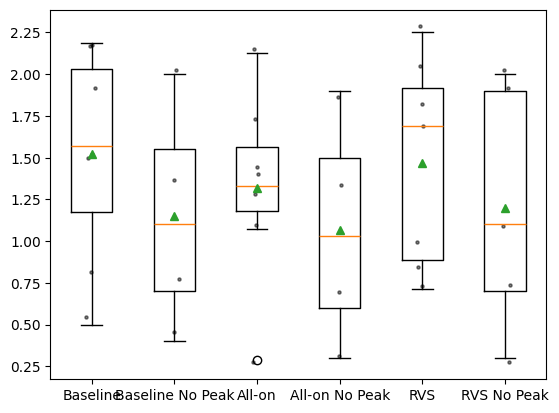

              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    subScore
No. Observations:      18         Method:                REML    
No. Groups:            9          Scale:                 0.0397  
Min. group size:       2          Log-Likelihood:        -4.9678 
Max. group size:       2          Converged:             Yes     
Mean group size:       2.0                                       
-----------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.05  0.95]
-----------------------------------------------------------------
Intercept               -0.117    0.155 -0.759 0.448 -0.372 0.137
Stage[T.C) RVS no peak]  0.059    0.141  0.420 0.675 -0.173 0.291
Stage[T.D) All-on peak]  0.053    0.208  0.255 0.799 -0.289 0.394
Stage[T.E) RVS peak]     0.230    0.208  1.109 0.267 -0.111 0.572
Group Var                0.056    0.288                          

<Wald test (chi2): stat

C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [41]:
#S4A
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_peaked"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a))
        rr.append(np.array(r))
        bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb))
        all.append( np.nanmean(aa))
        rvs.append( np.nanmean(rr))
    else:
        np_base.append(np.nanmean(bb))
        np_all.append( np.nanmean(aa))
        np_rvs.append( np.nanmean(rr))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

df_clean = updrs_label.dropna(subset=["Score"]).copy()
df_clean = (
    df_clean.groupby(["Patient Number", "Stage"])["Score"].mean().reset_index()
)
baseline_means = (
    df_clean[df_clean["Stage"] == "A) DBS-off"].groupby("Patient Number")["Score"].mean()
)
df_clean["Baseline"] = df_clean["Patient Number"].map(baseline_means)
df_clean["subScore"] = df_clean["Score"] - df_clean["Baseline"]
df_clean = df_clean.drop(columns=["Baseline"])
df_clean = df_clean[df_clean["Patient Number"] != 7]
df_clean = df_clean[df_clean["Patient Number"] != 3]
df_clean2 = df_clean[df_clean["Stage"] != "A) DBS-off"]
model = smf.mixedlm("subScore ~ Stage", data=df_clean2, groups=df_clean2["Patient Number"]).fit(method=["lbfgs"])
print(model.summary(alpha=0.10))
print(model.wald_test("Intercept = 0"))
print(model.wald_test("Stage[T.C) RVS no peak] = 0"))
print(model.wald_test("Stage[T.D) All-on peak] = 0"))
print(model.wald_test("Stage[T.E) RVS peak] = 0"))



# Supp. Fig. 4B:

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


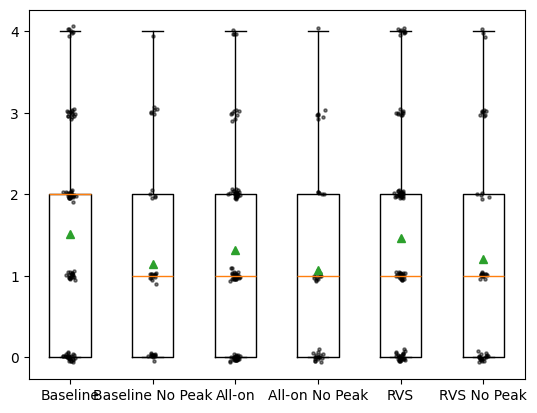

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     Score    
No. Observations:      373         Method:                 REML     
No. Groups:            11          Scale:                  1.2004   
Min. group size:       20          Log-Likelihood:         -577.9776
Max. group size:       48          Converged:              Yes      
Mean group size:       33.9                                         
--------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.05  0.95]
--------------------------------------------------------------------
Intercept                   1.321    0.211  6.249 0.000  0.973 1.669
Stage[T.B) All-on no peak] -0.078    0.225 -0.347 0.729 -0.447 0.292
Stage[T.C) RVS no peak]     0.069    0.208  0.332 0.740 -0.273 0.411
Stage[T.D) All-on peak]    -0.068    0.179 -0.379 0.704 -0.362 0.226
Stage[T.E) RVS peak]        0.084    0.178  0.471 

C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [47]:
#S4B
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_all_peaked"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a))
        rr.append(np.array(r))
        bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(bb)
        all.append(aa)
        rvs.append(rr)
    else:
        np_base.append(bb)
        np_all.append(aa)
        np_rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)
basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

basec = [
    x
    for xs in np_base
    for x in xs
    ]
allc = [
    x
    for xs in np_all
    for x in xs
    ]
rvsc = [
    x
    for xs in np_rvs
    for x in xs
    ]
np_base = np.array(basec)[~np.isnan(basec)]
np_all  = np.array(allc)[~np.isnan(allc)]
np_rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

df_clean2 = updrs_label.dropna(subset=["Score"]).copy()
model = smf.mixedlm("Score ~ Stage", data=df_clean2, groups=df_clean2["Patient Number"]).fit(method=["lbfgs"])
print(model.summary(alpha=0.10))
print(model.wald_test("Stage[T.B) All-on no peak] = 0"))
print(model.wald_test("Stage[T.C) RVS no peak] = 0"))
print(model.wald_test("Stage[T.D) All-on peak] = 0"))
print(model.wald_test("Stage[T.E) RVS peak] = 0"))

# Fig 4 C

C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\590282472.py:51: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\590282472.py:50: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\590282472.py:51: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\590282472.py:52: RuntimeWarning: Mean of empty slice
  np_rvs.append( np.nanmean(rr)-np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


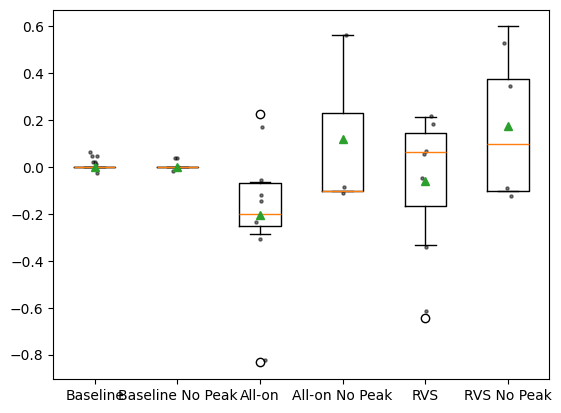

              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    subScore
No. Observations:      18         Method:                REML    
No. Groups:            9          Scale:                 0.0397  
Min. group size:       2          Log-Likelihood:        -4.9678 
Max. group size:       2          Converged:             Yes     
Mean group size:       2.0                                       
-----------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.05  0.95]
-----------------------------------------------------------------
Intercept               -0.117    0.155 -0.759 0.448 -0.372 0.137
Stage[T.C) RVS no peak]  0.059    0.141  0.420 0.675 -0.173 0.291
Stage[T.D) All-on peak]  0.053    0.208  0.255 0.799 -0.289 0.394
Stage[T.E) RVS peak]     0.230    0.208  1.109 0.267 -0.111 0.572
Group Var                0.056    0.288                          

<Wald test (chi2): stat

C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [42]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_difference_peaked"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a))
        rr.append(np.array(r))
        bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb)-np.nanmean(bb))
        all.append( np.nanmean(aa)-np.nanmean(bb))
        rvs.append( np.nanmean(rr)-np.nanmean(bb))
    else:
        np_base.append(np.nanmean(bb)-np.nanmean(bb))
        np_all.append( np.nanmean(aa)-np.nanmean(bb))
        np_rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

df_clean = updrs_label.dropna(subset=["Score"]).copy()
df_clean = (
    df_clean.groupby(["Patient Number", "Stage"])["Score"].mean().reset_index()
)
baseline_means = (
    df_clean[df_clean["Stage"] == "A) DBS-off"].groupby("Patient Number")["Score"].mean()
)
df_clean["Baseline"] = df_clean["Patient Number"].map(baseline_means)
df_clean["subScore"] = df_clean["Score"] - df_clean["Baseline"]
df_clean = df_clean.drop(columns=["Baseline"])
df_clean = df_clean[df_clean["Patient Number"] != 7]
df_clean = df_clean[df_clean["Patient Number"] != 3]
df_clean2 = df_clean[df_clean["Stage"] != "A) DBS-off"]
model = smf.mixedlm("subScore ~ Stage", data=df_clean2, groups=df_clean2["Patient Number"]).fit(method=["lbfgs"])
print(model.summary(alpha=0.10))
print(model.wald_test("Intercept = 0"))
print(model.wald_test("Stage[T.C) RVS no peak] = 0"))
print(model.wald_test("Stage[T.D) All-on peak] = 0"))
print(model.wald_test("Stage[T.E) RVS peak] = 0"))


# Fig. 4F

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


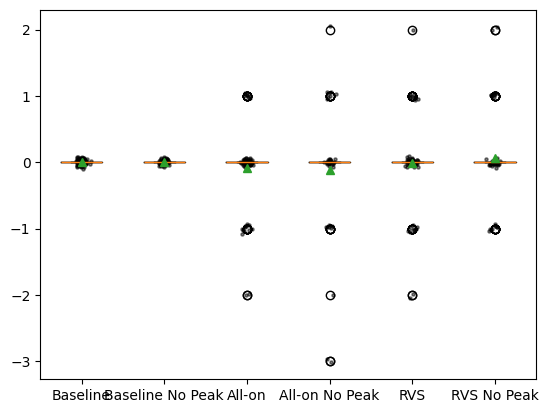

     Patient Number           Stage      Item Number  \
16                1  D) All-on peak        3.4.Glove   
17                1  D) All-on peak     3.4.NonGlove   
18                1  D) All-on peak        3.5.Glove   
19                1  D) All-on peak     3.5.NonGlove   
20                1  D) All-on peak        3.6.Glove   
..              ...             ...              ...   
368               9  C) RVS no peak       3.15.Glove   
369               9  C) RVS no peak    3.16.NonGlove   
370               9  C) RVS no peak       3.16.Glove   
371               9  C) RVS no peak  3.17.NonGloveUE   
372               9  C) RVS no peak     3.17.GloveUE   

                                    Item Description  Score  Baseline_Score  \
16                            Finger Tapping - Glove    2.0             2.0   
17                         Finger Tapping - NonGlove    3.0             3.0   
18                            Hand Movements - Glove    2.0             2.0   
19         

C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [43]:
# 4F
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_all_difference_peak_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,8,9]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a)-np.array(b))
        rr.append(np.array(r)-np.array(b))
        bb.append(0)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(bb)
        all.append(aa)
        rvs.append(rr)
    else:
        np_base.append(bb)
        np_all.append(aa)
        np_rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)
basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

basec = [
    x
    for xs in np_base
    for x in xs
    ]
allc = [
    x
    for xs in np_all
    for x in xs
    ]
rvsc = [
    x
    for xs in np_rvs
    for x in xs
    ]
np_base = np.array(basec)[~np.isnan(basec)]
np_all  = np.array(allc)[~np.isnan(allc)]
np_rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

df_clean = updrs_label.dropna(subset=["Score"]).copy()
baseline_means = (
    df_clean[df_clean["Stage"] == "A) DBS-off"]
    .groupby(["Patient Number", "Item Number"])["Score"]
    .mean()
    .reset_index()
    .rename(columns={"Score": "Baseline_Score"})
)
df_subtracted = pd.merge(
    df_clean, baseline_means, on=["Patient Number", "Item Number"], how="left"
)
df_subtracted["subScore"] = (
    df_subtracted["Score"] - df_subtracted["Baseline_Score"]
)
df_clean2 = df_subtracted[df_subtracted["Stage"] != "A) DBS-off"].copy()
df_clean2 = df_clean2[df_clean2["Patient Number"] != 7]
df_clean2 = df_clean2[df_clean2["Patient Number"] != 3]
df_clean2 = df_clean2[df_clean2["Stage"] != "A) DBS-off"]
df_clean2 = df_clean2.dropna(subset=["subScore"]).copy()
print(df_clean2)
model = smf.mixedlm("subScore ~ Stage - 1", data=df_clean2, groups=df_clean2["Patient Number"]).fit()
print(model.summary(alpha=0.10))
print(model.wald_test("Stage[B) All-on no peak] = 0"))
print(model.wald_test("Stage[C) RVS no peak] = 0"))
print(model.wald_test("Stage[D) All-on peak] = 0"))
print(model.wald_test("Stage[E) RVS peak] = 0"))


# and best for last
# Supp Fig 4C (1 of 2)

C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\3568081209.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\3568081209.py:51: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\3568081209.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\3568081209.py:53: RuntimeWarning: Mean of empty slice
  np_rvs.append( np.nanmean(rr)-np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


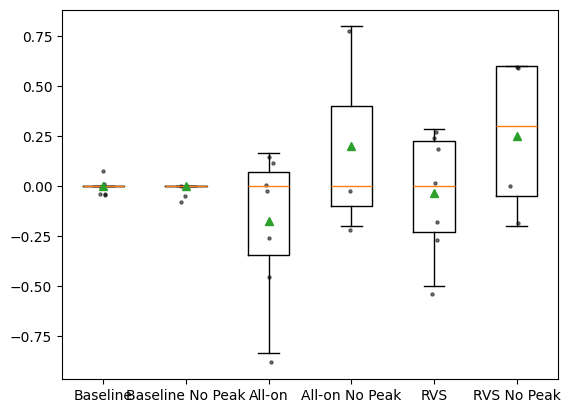

In [50]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_difference_peaked_gloveside"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        if ".Glove" in str(p2[1]["Item Number"].iloc[0]):
            b = []
            a = []
            r = []
            for x3,p3 in enumerate(p2[1].groupby("Stage")):
                if p3[1]["Stage"].iloc[0] == "Baseline":
                    b.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 1":
                    if ix == "dbs_off,all_on,rvs":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 2":
                    if ix == "dbs_off,rvs,all_on":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])   
                        
            #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
            aa.append(np.array(a))
            rr.append(np.array(r))
            bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb)-np.nanmean(bb))
        all.append( np.nanmean(aa)-np.nanmean(bb))
        rvs.append( np.nanmean(rr)-np.nanmean(bb))
    else:
        np_base.append(np.nanmean(bb)-np.nanmean(bb))
        np_all.append( np.nanmean(aa)-np.nanmean(bb))
        np_rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs

# Supp Fig 4C (2 of 2)

C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\401432536.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\401432536.py:51: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\401432536.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_2636\401432536.py:53: RuntimeWarning: Mean of empty slice
  np_rvs.append( np.nanmean(rr)-np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


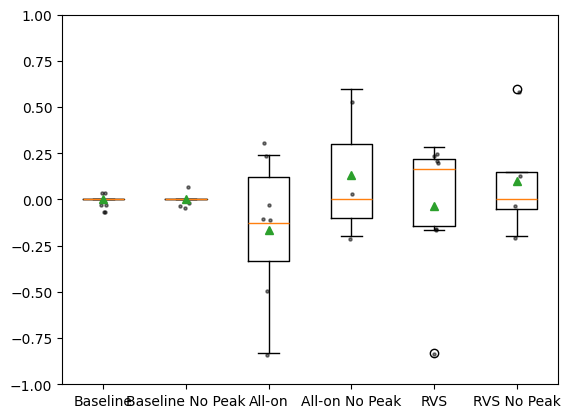

                        Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           subScore 
No. Observations:           222               Method:                       REML     
No. Groups:                 9                 Scale:                        1.2312   
Min. group size:            20                Log-Likelihood:               -340.1487
Max. group size:            32                Converged:                    Yes      
Mean group size:            24.7                                                     
-------------------------------------------------------------------------------------
                                            Coef.  Std.Err.   z    P>|z| [0.05  0.95]
-------------------------------------------------------------------------------------
Intercept                                   -0.082    0.246 -0.333 0.739 -0.486 0.323
Stage[T.C) RVS no peak]                      0.088    0.339  0.259 0.795 -0.46

C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [53]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_difference_peaked_Nongloveside"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        if ".NonGlove" in str(p2[1]["Item Number"].iloc[0]):
            b = []
            a = []
            r = []
            for x3,p3 in enumerate(p2[1].groupby("Stage")):
                if p3[1]["Stage"].iloc[0] == "Baseline":
                    b.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 1":
                    if ix == "dbs_off,all_on,rvs":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 2":
                    if ix == "dbs_off,rvs,all_on":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])   
                        
            #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
            aa.append(np.array(a))
            rr.append(np.array(r))
            bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb)-np.nanmean(bb))
        all.append( np.nanmean(aa)-np.nanmean(bb))
        rvs.append( np.nanmean(rr)-np.nanmean(bb))
    else:
        np_base.append(np.nanmean(bb)-np.nanmean(bb))
        np_all.append( np.nanmean(aa)-np.nanmean(bb))
        np_rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
ax = plt.gca()
ax.set_ylim([-1, 1])
plt.savefig(filename+".svg")
plt.savefig(filename+".png")

plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs


df_clean = updrs_label.dropna(subset=["Score"]).copy()
df_clean = (df_clean.groupby(["Patient Number", "Item Number", "Stage"])["Score"].mean().reset_index())
baseline_means = (
    df_clean[df_clean["Stage"] == "A) DBS-off"].groupby("Patient Number")["Score"].mean()
)
df_clean["Is_NonGlove"] = df_clean["Item Number"].str.contains(
    "NonGlove", case=False, na=False
)

df_clean["Baseline"] = df_clean["Patient Number"].map(baseline_means)
df_clean["subScore"] = df_clean["Score"] - df_clean["Baseline"]
df_clean = df_clean.drop(columns=["Baseline"])
df_clean = df_clean[df_clean["Patient Number"] != 7]
df_clean = df_clean[df_clean["Patient Number"] != 3]
df_clean2 = df_clean[df_clean["Stage"] != "A) DBS-off"]
model = smf.mixedlm("subScore ~ Stage * Is_NonGlove", data=df_clean2, groups=df_clean2["Patient Number"]).fit()
print(model.summary(alpha=0.10))
print(model.wald_test("Intercept = 0"))
print(model.wald_test("Stage[T.C) RVS no peak] = 0"))
print(model.wald_test("Stage[T.D) All-on peak] = 0"))
print(model.wald_test("Stage[T.E) RVS peak] = 0"))
print(model.wald_test("Intercept - Stage[T.D) All-on peak] = 0"))
print(model.wald_test("Stage[T.C) RVS no peak] - Stage[T.C) RVS no peak]:Is_NonGlove[T.True] = 0"))
print(model.wald_test("Stage[T.D) All-on peak] - Stage[T.D) All-on peak]:Is_NonGlove[T.True]= 0"))
print(model.wald_test("Stage[T.E) RVS peak] - Stage[T.E) RVS peak]:Is_NonGlove[T.True]  = 0"))
